In [1]:
#ASSIGNMENT 3 ML Project

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from scipy.stats import skew
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

In [21]:
from sklearn . datasets import fetch_openml
har = fetch_openml ( name ="har", version =1 , as_frame = True )
X , y = har . data , har . target . astype ( int)

In [23]:
print(har)

{'data':              V1        V2        V3        V4        V5        V6        V7  \
0      0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112   
1      0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807   
2      0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520   
3      0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675 -0.997099   
4      0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482 -0.998321   
...         ...       ...       ...       ...       ...       ...       ...   
10294  0.310155 -0.053391 -0.099109 -0.287866 -0.140589 -0.215088 -0.356083   
10295  0.363385 -0.039214 -0.105915 -0.305388  0.028148 -0.196373 -0.373540   
10296  0.349966  0.030077 -0.115788 -0.329638 -0.042143 -0.250181 -0.388017   
10297  0.237594  0.018467 -0.096499 -0.323114 -0.229775 -0.207574 -0.392380   
10298  0.153627 -0.018437 -0.137018 -0.330046 -0.195253 -0.164339 -0.430974   

             V8        V9       V10  ...  

In [27]:
print(har.data.describe())

                 V1            V2            V3            V4            V5  \
count  10299.000000  10299.000000  10299.000000  10299.000000  10299.000000   
mean       0.274347     -0.017743     -0.108925     -0.607784     -0.510191   
std        0.067628      0.037128      0.053033      0.438694      0.500240   
min       -1.000000     -1.000000     -1.000000     -1.000000     -1.000000   
25%        0.262624     -0.024903     -0.121019     -0.992360     -0.976990   
50%        0.277174     -0.017162     -0.108596     -0.943030     -0.835032   
75%        0.288354     -0.010625     -0.097589     -0.250293     -0.057336   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

                 V6            V7            V8            V9           V10  \
count  10299.000000  10299.000000  10299.000000  10299.000000  10299.000000   
mean      -0.613064     -0.633593     -0.525697     -0.614989     -0.466732   
std        0.403657      0.413333      0.484201    

In [29]:
print(har.target.describe())

count     10299
unique        6
top           6
freq       1944
Name: Class, dtype: object


In [ ]:
#DATA PREPROCESSING

In [31]:
miss_data=X.isnull().values.any()
miss_target=pd.Series(y).isnull().values.any()

print("Is there any missing feature : ", miss_data)
print("Is there any missing target :", miss_target)

Is there any missing feature :  False
Is there any missing target : False


In [35]:
features=har.data
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (features < (Q1 - 1.5 * IQR)) | (features > (Q3 + 1.5 * IQR))

print("IQR Outlier:\n",outlier_mask.sum().sort_values(ascending=False))
print("Total rows has IQR outliers: ",outlier_mask.any(axis=1).sum())

IQR Outlier:
 V81     3871
V121    3290
V161    3148
V82     3064
V162    3048
        ... 
V80        0
V104       0
V524       0
V368       0
V281       0
Length: 561, dtype: int64
Total rows has IQR outliers:  9642


In [37]:
z_scores = np.abs(zscore(features))
outliers_z = (z_scores > 3)
print("Total rows with Z-score outlier:", outliers_z.any(axis=1).sum())

Total rows with Z-score outlier: 6481


In [39]:
#STANDARDIZATION

scaler = StandardScaler()
X_standardized = scaler.fit_transform(features)
X_data = pd.DataFrame(X_standardized, columns=features.columns)

print(X_data.head(5))

         V1        V2        V3        V4        V5        V6        V7  \
0  0.210541 -0.068698 -0.452192 -0.883336 -0.945432 -0.744386 -0.874687   
1  0.060211  0.035891 -0.275218 -0.890097 -0.929817 -0.860322 -0.883627   
2  0.078459 -0.046423 -0.085554 -0.883566 -0.913597 -0.906457 -0.878093   
3  0.071376 -0.227803 -0.270749 -0.885187 -0.946016 -0.935521 -0.879494   
4  0.033741  0.031608 -0.121382 -0.889856 -0.940846 -0.935042 -0.882451   

         V8        V9       V10  ...      V552      V553      V554      V555  \
0 -0.944878 -0.773250 -0.868774  ... -0.819093 -0.000263 -0.299902 -0.357897   
1 -0.927796 -0.858858 -0.884264  ...  0.127804 -0.925905 -0.789554  0.135993   
2 -0.904569 -0.908438 -0.876140  ...  1.172611 -0.287823 -0.461182 -0.375144   
3 -0.943980 -0.938096 -0.876140  ...  1.132151  0.566244  0.436734 -0.132194   
4 -0.937623 -0.940948 -0.883152  ... -0.158720 -0.165153 -0.263957  0.343504   

       V556      V557      V558      V559      V560      V561  
0  0

In [ ]:

y_data = pd.get_dummies(y)

print(y_data)

[4 4 4 ... 1 1 1]


In [43]:
skew_value = X_data.apply(skew)
skewed_features = skew_value[skew_value.abs() > 1]

print("High Skewwd features:")
print(skewed_features)

pos_skew = (skewed_features > 0).sum()
neg_skew = (skewed_features < 0).sum()

print("Number of positively skewed features:", pos_skew)
print("Number of negatively skewed features:", neg_skew)

High Skewwd features:
V1     -3.489894
V3      1.759392
V15    -1.133401
V17     1.734892
V18     1.918878
          ...   
V549    1.491689
V551    5.285573
V554    1.530795
V559    1.422962
V560   -1.425461
Length: 271, dtype: float64
Number of positively skewed features: 258
Number of negatively skewed features: 13


In [ ]:
#EXPLORATORY DATA ANALYSIS

Class Distribution:
 0    1722
1    1544
2    1406
3    1777
4    1906
5    1944
Name: count, dtype: int64


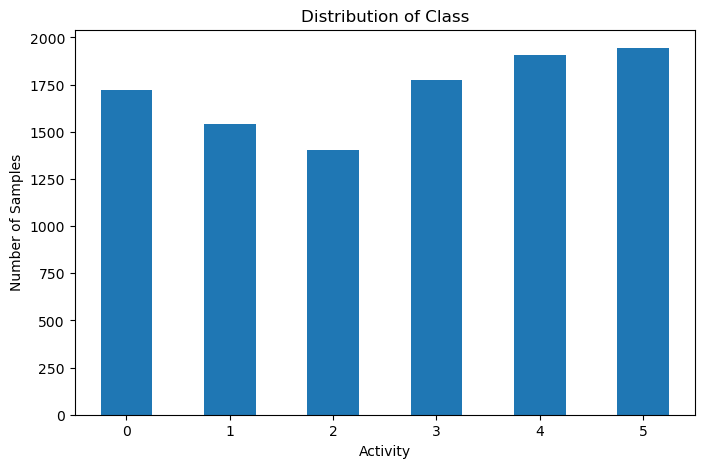

In [45]:
class_count = pd.Series(y_data).value_counts().sort_index()

print("Class Distribution:\n", class_count)

plt.figure(figsize=(8, 5))
class_count.plot(kind='bar')
plt.title("Distribution of Class")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [47]:
#correlation of features with target
f_val, p_val = f_classif(X_data, y_data)
Anova_feature = pd.DataFrame({'Feature': X_data.columns, 'F_value': f_val.round(2), 'p_value': p_val.round(3)})
Anova_feature = Anova_feature.sort_values(by='F_value', ascending=False)
print(Anova_feature.head(10))

    Feature   F_value  p_value
366    V367  50776.15      0.0
40      V41  46277.29      0.0
52      V53  44357.63      0.0
49      V50  41202.85      0.0
56      V57  40415.98      0.0
367    V368  37518.06      0.0
523    V524  32616.29      0.0
234    V235  32507.55      0.0
287    V288  32200.82      0.0
102    V103  31258.37      0.0


Top 10 features:
     Feature  Importance
50      V51    0.008689
41      V42    0.005534
37      V38    0.004029
56      V57    0.003883
450    V451    0.003155
129    V130    0.003010
57      V58    0.001650
409    V410    0.001553
53      V54    0.001214
179    V180    0.001165


<Figure size 800x500 with 0 Axes>

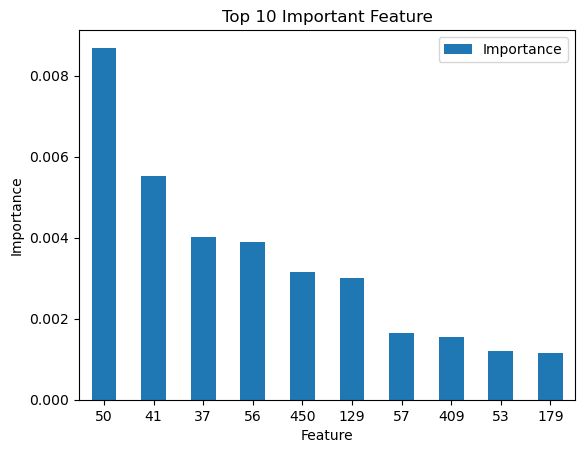

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)

imp_feature = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')

imp_data = pd.DataFrame({
    'Feature': X_data.columns,
    'Importance': imp_feature.importances_mean
}).sort_values(by='Importance', ascending=False)

feature_10 = imp_data.head(10)

print("Top 10 features:\n", feature_10)

plt.figure(figsize=(8, 5))
feature_10.plot(kind='bar')
plt.title("Top 10 Important Feature")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Modeling

In [61]:
import tensorflow
from tensorflow import keras
print(keras._version_)

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# X_data, y_data already defined
num_classes = len(np.unique(y_data))

accuracies, f1_scores, auc_scores = [], [], []

for i in range(5):
    seed = np.random.randint(42, 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=seed, stratify=y_data
    )

    # Scale using train stats only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    

    model = Sequential([
        Dense(10, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(10, activation='relu'),
        Dense(10, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train_scaled, y_data,
        validation_data=(X_test_scaled, y_data
                         ),  # <-- use y_test_c here
        epochs=50, batch_size=32, verbose=0
    )

    # Predictions
    y_prob = model.predict(X_test_scaled, verbose=0)   # shape: (n_samples, num_classes)
    y_pred = np.argmax(y_prob, axis=1)

    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred, average='weighted'))
    auc_scores.append(roc_auc_score(y_test_c, y_prob, multi_class='ovr', average='weighted'))

    # Report mean ± std so far
    print(f"Experiment: {i}")
    print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"F1-score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print(f"AUC-ROC:  {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

    # (Optional) Micro-average ROC curve across all classes for this run
    fpr, tpr, _ = roc_curve(y_test_c.ravel(), y_prob.ravel())
    plt.plot(fpr, tpr, label=f'Run {i}')
    plt.plot([0, 1], [0, 1], linestyle='-')  # diagonal
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Micro-average ROC (per run)")
    plt.legend()
    plt.show()


ModuleNotFoundError: No module named 'tensorflow'

In [51]:
num_classes = len(np.unique(y_data))
accuracies, f1_scores, auc_scores = [], [], []

for i in range(5):
    seed = np.random.randint(42, 100)
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=seed, stratify=y_data)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # One-hot encode AFTER split
    y_train_c = to_categorical(y_train, num_classes=num_classes)
    y_test_c  = to_categorical(y_test,  num_classes=num_classes)

    model = Sequential([
        Dense(10, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(10, activation='relu'),
        Dense(10, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    ep_ran = np.random.randint(10, 30)
    history = model.fit(
        X_train_scaled, y_train_c,
        validation_data=(X_test_scaled, y_test_c),  # <-- correct labels
        epochs=ep_ran, batch_size=32, verbose=0
    )

    # Predict
    y_prob = model.predict(X_test_scaled, verbose=0)  # (n_samples, num_classes)
    y_pred = np.argmax(y_prob, axis=1)

    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred, average='weighted'))
    auc_scores.append(roc_auc_score(y_test_c, y_prob, multi_class='ovr', average='weighted'))

    # Report mean ± std so far
    print(f"Experiment: {i+1}")
    print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"F1-score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print(f"AUC-ROC:  {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

    # ROC guide line (optional to add actual curves per class)
    plt.plot([0, 1], [0, 1], linestyle='-')  # no color set
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Across Runs")
    plt.show()

NameError: name 'to_categorical' is not defined